In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
df = pd.read_csv("../data/processed/final_financial_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (9802, 25)


,Transaction_ID,Transaction_Date,Company_Code,Cost_Center,Profit_Center,Account_Category,Transaction_Type,Amount,Budget,Payment_Status,...,Vendor_ID,Tax_Amount,Profit,Approval_Status,Anomaly_Indicator,Year,Month,Quarter,Budget_Variance,Budget_Utilization
0,TX005450,2024-01-17,C003,CC107,PC206,Procurement,Expense,660134.88,870600.30,Pending,...,NaN,115121.44,NaN,Approved,0,2024,1,1,-210465.42,75.825253
1,TX000061,2021-01-21,C001,CC111,PC202,Marketing,Expense,226317.84,255507.62,Paid,...,V040,42898.57,NaN,Approved,0,2021,1,1,-29189.78,88.575769
2,TX007730,2025-10-02,C002,CC105,PC206,Marketing,Expense,381300.39,427732.69,Partially Paid,...,V035,70826.38,NaN,Approved,0,2025,10,4,-46432.30,89.144552
3,TX003695,2023-02-14,C002,CC112,PC204,Procurement,Expense,352712.21,360120.03,Partially Paid,...,V001,62394.66,NaN,Approved,0,2023,2,1,-7407.82,97.942958
4,TX001800,2022-02-25,C005,CC104,PC206,Sales,Revenue,599713.69,603576.07,Paid,...,NaN,109719.59,164961.87,Pending,0,2022,2,1,-3862.38,99.360084


In [6]:
df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    format="mixed",
    dayfirst=True
)

print(df["Transaction_Date"].dtype)

datetime64[ns]


In [7]:
df["Year_Month"] = df["Transaction_Date"].dt.to_period("M")

df[["Transaction_Date", "Year_Month"]].head()

,Transaction_Date,Year_Month
0,2024-01-17,2024-01
1,2021-01-21,2021-01
2,2025-10-02,2025-10
3,2023-02-14,2023-02
4,2022-02-25,2022-02


In [8]:
monthly_financials = (
    df.groupby(["Year_Month", "Transaction_Type"])["Amount"]
    .sum()
    .unstack(fill_value=0)
)

monthly_financials.head()

Transaction_Type,Expense,Revenue
Year_Month,,
2021-01,14709639.29,8437831.52
2021-02,14371577.45,11672693.16
2021-03,29949213.44,15201713.77
2021-04,17251021.57,11762185.49
2021-05,18282795.56,9830046.88


In [9]:
print("Number of months:", len(monthly_financials))
print("Start:", monthly_financials.index.min())
print("End:", monthly_financials.index.max())

Number of months: 60
Start: 2021-01
End: 2025-12


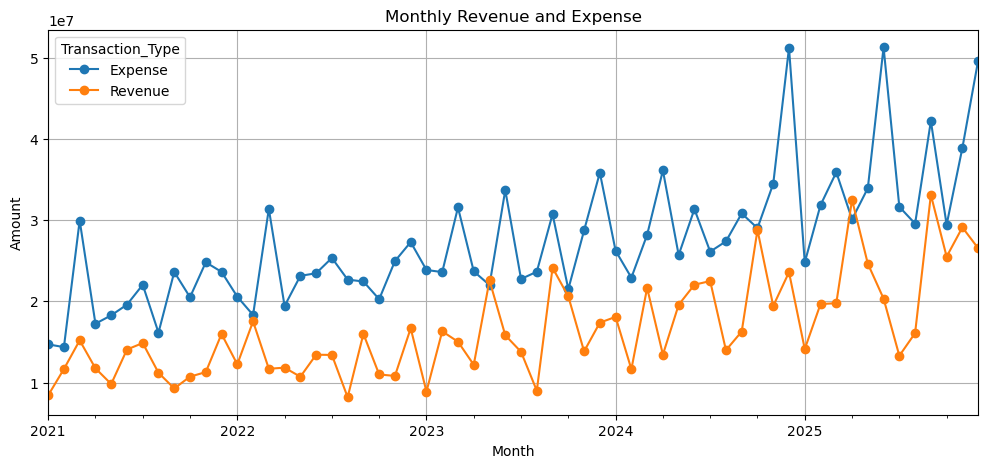

In [10]:
monthly_financials.plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Revenue and Expense")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)

plt.show()

In [11]:
expense_series = monthly_financials[["Expense"]].copy()

expense_series.head()

Transaction_Type,Expense
Year_Month,
2021-01,14709639.29
2021-02,14371577.45
2021-03,29949213.44
2021-04,17251021.57
2021-05,18282795.56


In [12]:
print("Number of observations:", len(expense_series))
print("Missing values:", expense_series["Expense"].isnull().sum())

Number of observations: 60
Missing values: 0


In [13]:
train = expense_series.loc[:'2024']
test = expense_series.loc['2025']

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 48
Testing observations: 12


In [14]:
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())

Training period: 2021-01 to 2024-12
Testing period: 2025-01 to 2025-12


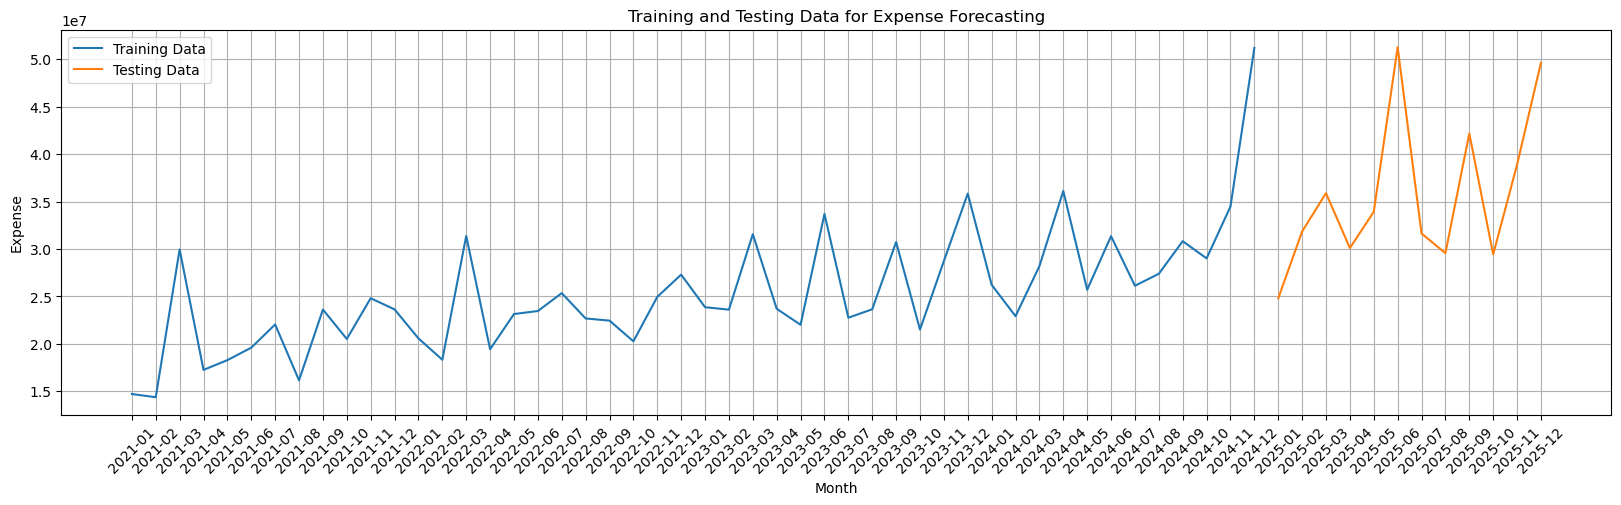

In [20]:
plt.figure(figsize=(20, 5))

plt.plot(
    train.index.astype(str),
    train["Expense"],
    label="Training Data"
)

plt.plot(
    test.index.astype(str),
    test["Expense"],
    label="Testing Data"
)

plt.title("Training and Testing Data for Expense Forecasting")
plt.xlabel("Month")
plt.ylabel("Expense")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [21]:
forecast_df = expense_series.copy()

forecast_df["Lag_1"] = forecast_df["Expense"].shift(1)
forecast_df["Lag_2"] = forecast_df["Expense"].shift(2)
forecast_df["Lag_3"] = forecast_df["Expense"].shift(3)
forecast_df["Lag_12"] = forecast_df["Expense"].shift(12)

forecast_df.head(15)

Transaction_Type,Expense,Lag_1,Lag_2,Lag_3,Lag_12
Year_Month,,,,,
2021-01,14709639.29,NaN,NaN,NaN,NaN
2021-02,14371577.45,14709639.29,NaN,NaN,NaN
2021-03,29949213.44,14371577.45,14709639.29,NaN,NaN
2021-04,17251021.57,29949213.44,14371577.45,14709639.29,NaN
2021-05,18282795.56,17251021.57,29949213.44,14371577.45,NaN
2021-06,19595332.25,18282795.56,17251021.57,29949213.44,NaN
2021-07,22041920.61,19595332.25,18282795.56,17251021.57,NaN
2021-08,16150946.12,22041920.61,19595332.25,18282795.56,NaN
2021-09,23615048.80,16150946.12,22041920.61,19595332.25,NaN


In [23]:
forecast_df["Rolling_Mean_3"] = (
    forecast_df["Expense"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

forecast_df.head(15)

Transaction_Type,Expense,Lag_1,Lag_2,Lag_3,Lag_12,Rolling_Mean_3
Year_Month,,,,,,
2021-01,14709639.29,NaN,NaN,NaN,NaN,NaN
2021-02,14371577.45,14709639.29,NaN,NaN,NaN,NaN
2021-03,29949213.44,14371577.45,14709639.29,NaN,NaN,NaN
2021-04,17251021.57,29949213.44,14371577.45,14709639.29,NaN,1.967681e+07
2021-05,18282795.56,17251021.57,29949213.44,14371577.45,NaN,2.052394e+07
2021-06,19595332.25,18282795.56,17251021.57,29949213.44,NaN,2.182768e+07
2021-07,22041920.61,19595332.25,18282795.56,17251021.57,NaN,1.837638e+07
2021-08,16150946.12,22041920.61,19595332.25,18282795.56,NaN,1.997335e+07
2021-09,23615048.80,16150946.12,22041920.61,19595332.25,NaN,1.926273e+07


In [24]:
forecast_df["Month"] = forecast_df.index.month
forecast_df["Quarter"] = forecast_df.index.quarter

forecast_df.head()

Transaction_Type,Expense,Lag_1,Lag_2,Lag_3,Lag_12,Rolling_Mean_3,Month,Quarter
Year_Month,,,,,,,,
2021-01,14709639.29,NaN,NaN,NaN,NaN,NaN,1,1
2021-02,14371577.45,14709639.29,NaN,NaN,NaN,NaN,2,1
2021-03,29949213.44,14371577.45,14709639.29,NaN,NaN,NaN,3,1
2021-04,17251021.57,29949213.44,14371577.45,14709639.29,NaN,1.967681e+07,4,2
2021-05,18282795.56,17251021.57,29949213.44,14371577.45,NaN,2.052394e+07,5,2


In [25]:
forecast_df = forecast_df.dropna()

print("Forecast dataset shape:", forecast_df.shape)
forecast_df.head()

Forecast dataset shape: (48, 8)


Transaction_Type,Expense,Lag_1,Lag_2,Lag_3,Lag_12,Rolling_Mean_3,Month,Quarter
Year_Month,,,,,,,,
2022-01,20572753.71,23630452.56,24807555.04,20512076.95,14709639.29,2.298336e+07,1,1
2022-02,18323713.93,20572753.71,23630452.56,24807555.04,14371577.45,2.300359e+07,2,1
2022-03,31371486.99,18323713.93,20572753.71,23630452.56,29949213.44,2.084231e+07,3,1
2022-04,19431593.86,31371486.99,18323713.93,20572753.71,17251021.57,2.342265e+07,4,2
2022-05,23141273.03,19431593.86,31371486.99,18323713.93,18282795.56,2.304226e+07,5,2


In [26]:
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 48 entries, 2022-01 to 2025-12
Freq: M
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Expense         48 non-null     float64
 1   Lag_1           48 non-null     float64
 2   Lag_2           48 non-null     float64
 3   Lag_3           48 non-null     float64
 4   Lag_12          48 non-null     float64
 5   Rolling_Mean_3  48 non-null     float64
 6   Month           48 non-null     int64  
 7   Quarter         48 non-null     int64  
dtypes: float64(6), int64(2)
memory usage: 3.4 KB


In [27]:
forecast_df.isnull().sum()

Transaction_Type
Expense           0
Lag_1             0
Lag_2             0
Lag_3             0
Lag_12            0
Rolling_Mean_3    0
Month             0
Quarter           0
dtype: int64

In [28]:
train = forecast_df.loc[:'2024']
test = forecast_df.loc['2025']

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training shape: (36, 8)
Testing shape: (12, 8)

Training period:
2022-01 to 2024-12

Testing period:
2025-01 to 2025-12


In [29]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_12",
    "Rolling_Mean_3",
    "Month",
    "Quarter"
]

X_train = train[features]
y_train = train["Expense"]

X_test = test[features]
y_test = test["Expense"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (36, 7)
y_train: (36,)
X_test: (12, 7)
y_test: (12,)
